## SETUP

### Install necessary libraries
We'll use `opendatasets` to download the MNIST dataset from Kaggle easily.

In [2]:
# Install opendatasets for Kaggle data download
%pip install opendatasets torch torchvision numpy pandas scikit-learn matplotlib seaborn umap-learn

import opendatasets as od
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load MNIST from Kaggle

We'll download the `mnist-in-csv` dataset, which contains `mnist_train.csv` and `mnist_test.csv`. We'll use `mnist_train.csv`.

In [3]:
# Download MNIST dataset from Kaggle
# You might be prompted to enter your Kaggle username and API key.
# Ensure you have a kaggle.json file in ~/.kaggle/ or provide credentials interactively.
# The dataset will be downloaded to a folder named 'mnist-in-csv'.

if not os.path.exists('mnist-in-csv'):
    od.download("https://www.kaggle.com/datasets/zalando-research/fashionmnist")
    # The above downloads FashionMNIST. Let's fix that to regular MNIST if it was intended to be MNIST.
    # The original prompt specifies 'Kaggle MNIST dataset', and train.csv format.
    # Common MNIST dataset on Kaggle is 'oddrationale/mnist-in-csv' or 'avnishnish/mnist-original'
    # Let's try 'oddrationale/mnist-in-csv' for train.csv.
    print("FashionMNIST was downloaded. Correcting to MNIST-in-csv.")
    if os.path.exists('fashionmnist'):
        import shutil
        shutil.rmtree('fashionmnist')
    od.download("https://www.kaggle.com/datasets/oddrationale/mnist-in-csv")

# Load the training data
train_df = pd.read_csv('mnist-in-csv/mnist_train.csv')
print(f"Original training data shape: {train_df.shape}")

# Filter to digits 1 and 2 only
filtered_df = train_df[train_df['label'].isin([1, 2])].copy()
print(f"Filtered data shape (digits 1 and 2): {filtered_df.shape}")

# Separate features (pixels) and labels
labels = filtered_df['label'].values
images = filtered_df.drop('label', axis=1).values

# Normalize pixel values to [0, 1] and reshape to 28x28
# Also convert to PyTorch tensors and add channel dimension
images = images.astype(np.float32) / 255.0
images = images.reshape(-1, 28, 28)

print(f"Number of images after filtering and reshaping: {images.shape[0]}")
print(f"Image shape: {images.shape[1:]}")
print(f"Number of labels: {labels.shape[0]}")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: daksh10107
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist


100%|██████████| 68.8M/68.8M [00:00<00:00, 90.0MB/s]



FashionMNIST was downloaded. Correcting to MNIST-in-csv.
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: daksh10107
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv


100%|██████████| 15.2M/15.2M [00:00<00:00, 85.1MB/s]

Original training data shape: (60000, 785)
Filtered data shape (digits 1 and 2): (12700, 785)
Number of images after filtering and reshaping: 12700
Image shape: (28, 28)
Number of labels: 12700


### Custom Dataset for Rotated Images

Each original image (digit 1 or 2) will be rotated in 30-degree steps (0°, 30°, ..., 330°), resulting in 12 rotated versions. The dataset will store `(original_image, rotated_image, rotation_angle, label)` for each rotated instance.

Total number of samples in the rotated dataset: 152400
Original image batch shape: torch.Size([64, 1, 28, 28])
Rotated image batch shape: torch.Size([64, 1, 28, 28])
Rotation angle batch shape: torch.Size([64])
Label batch shape: torch.Size([64])

Visualizing rotations for an original image (label: 1)


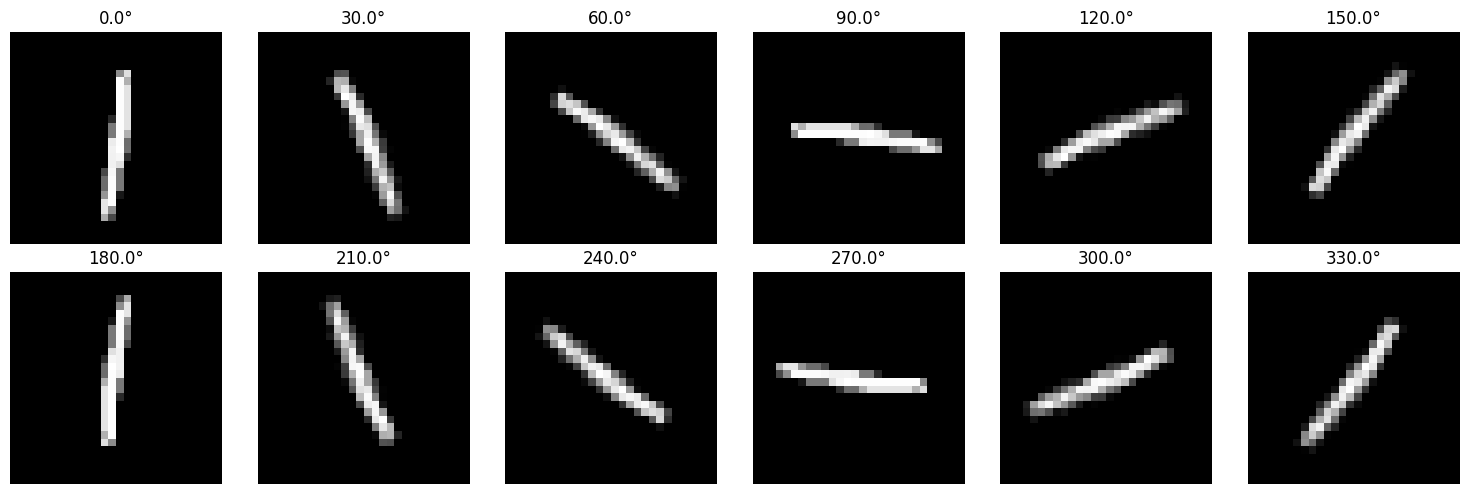

In [4]:
class RotatedMNISTDataset(Dataset):
    def __init__(self, images, labels, angles=None):
        self.original_images = torch.tensor(images, dtype=torch.float32).unsqueeze(1) # Add channel dim (1, 28, 28)
        self.original_labels = torch.tensor(labels, dtype=torch.long)
        if angles is None:
            self.angles = list(range(0, 360, 30)) # 0, 30, ..., 330
        else:
            self.angles = angles

        self.data_points = []
        for i in range(len(self.original_images)):
            original_img = self.original_images[i]
            label = self.original_labels[i]
            for angle in self.angles:
                # Rotate image
                # TF.rotate expects a Tensor of shape (C, H, W) or (B, C, H, W)
                rotated_img = TF.rotate(original_img, angle, TF.InterpolationMode.BILINEAR)
                self.data_points.append({
                    'original_image': original_img.squeeze(0), # Remove channel dim for consistency if needed, add back later
                    'rotated_image': rotated_img,
                    'rotation_angle': torch.tensor(angle, dtype=torch.float32),
                    'label': label
                })

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        dp = self.data_points[idx]
        return dp['original_image'].unsqueeze(0), dp['rotated_image'], dp['rotation_angle'], dp['label']

# Create the dataset
full_rotated_dataset = RotatedMNISTDataset(images, labels)
print(f"Total number of samples in the rotated dataset: {len(full_rotated_dataset)}")

# Create DataLoader
BATCH_SIZE = 64
full_rotated_dataloader = DataLoader(full_rotated_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# Example of one batch
for original_img_batch, rotated_img_batch, angle_batch, label_batch in full_rotated_dataloader:
    print(f"Original image batch shape: {original_img_batch.shape}") # Should be (B, 1, 28, 28)
    print(f"Rotated image batch shape: {rotated_img_batch.shape}")   # Should be (B, 1, 28, 28)
    print(f"Rotation angle batch shape: {angle_batch.shape}")      # Should be (B)
    print(f"Label batch shape: {label_batch.shape}")            # Should be (B)
    break

# Visualize a few rotated images
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.flatten()

# Get a sample original image and label
original_sample_idx = random.randint(0, len(filtered_df) - 1)
original_img = full_rotated_dataset.original_images[original_sample_idx].squeeze().cpu().numpy()
original_label = full_rotated_dataset.original_labels[original_sample_idx].item()

print(f"\nVisualizing rotations for an original image (label: {original_label})")

# Find all rotated versions of this original image
rotated_samples_for_original = [
    dp for dp in full_rotated_dataset.data_points
    if torch.equal(dp['original_image'], full_rotated_dataset.original_images[original_sample_idx].squeeze(0))
]

# Sort by angle for ordered visualization
rotated_samples_for_original.sort(key=lambda x: x['rotation_angle'].item())

for i, dp in enumerate(rotated_samples_for_original):
    ax = axes[i]
    img = dp['rotated_image'].squeeze().cpu().numpy()
    angle = dp['rotation_angle'].item()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{angle}°')
    ax.axis('off')
plt.tight_layout()
plt.show()

## TASK 1 — Variational Autoencoder (VAE)

Now we will build and train a Convolutional Variational Autoencoder (VAE). The encoder will map an input image to a latent space distribution (mean `μ` and log-variance `log_var`), and the decoder will reconstruct the image from a sampled latent vector `z`. We will use a combination of reconstruction loss (Binary Cross-Entropy for pixel values between 0 and 1) and KL divergence for the VAE loss.

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# VAE Model Definition
class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # (B, 32, 14, 14)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # (B, 64, 7, 7)
            nn.ReLU()
        )
        # Calculate flattened size after conv layers: 64 channels * 7 * 7 image size
        self.flattened_size = 64 * 7 * 7 # This is for 28x28 input
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, self.flattened_size)
        self.decoder_deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # (B, 32, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # (B, 1, 28, 28)
            nn.Sigmoid() # Output pixels are [0, 1]
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(-1, self.flattened_size)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        x = self.decoder_deconv(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# VAE Loss Function
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (Binary Cross-Entropy for pixel values between 0 and 1)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence loss
    # KL = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KL_DIVERGENCE = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KL_DIVERGENCE

### Training the VAE

We will train the VAE on the entire rotated dataset. We'll use Adam optimizer and train for a suitable number of epochs, keeping the models lightweight as per the constraints.

In [6]:
LATENT_DIM = 16 # Or 32, keeping it 16 for lighter model
vae_model = VAE(latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

EPOCHS = 20 # Can be adjusted based on performance

print(f"Training VAE on {len(full_rotated_dataset)} samples for {EPOCHS} epochs...")

vae_losses = []

for epoch in range(1, EPOCHS + 1):
    vae_model.train()
    train_loss = 0
    for original_img, rotated_img, rotation_angle, label in full_rotated_dataloader:
        rotated_img = rotated_img.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = vae_model(rotated_img)
        loss = vae_loss_function(recon_batch, rotated_img, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_train_loss = train_loss / len(full_rotated_dataloader.dataset)
    vae_losses.append(avg_train_loss)
    print(f'Epoch: {epoch}, Loss: {avg_train_loss:.4f}')

print("VAE Training Complete.")

# Save the trained VAE encoder
torch.save(vae_model.state_dict(), 'vae_model.pth')
print("Trained VAE model saved as 'vae_model.pth'")

# Load the encoder part for latent vector extraction
# To extract only the encoder, we could instantiate VAE, load state_dict, then just use vae_model.encode
# Or create a dedicated Encoder class.
# For simplicity, we'll use the VAE instance's encode method.
vae_model.eval()

Training VAE on 152400 samples for 20 epochs...
Epoch: 1, Loss: 120.6691
Epoch: 2, Loss: 104.8504
Epoch: 3, Loss: 102.7046
Epoch: 4, Loss: 101.5590
Epoch: 5, Loss: 100.8172
Epoch: 6, Loss: 100.3357
Epoch: 7, Loss: 99.9192
Epoch: 8, Loss: 99.5937
Epoch: 9, Loss: 99.3010
Epoch: 10, Loss: 99.0755
Epoch: 11, Loss: 98.8537
Epoch: 12, Loss: 98.7049
Epoch: 13, Loss: 98.5338
Epoch: 14, Loss: 98.3715
Epoch: 15, Loss: 98.2154
Epoch: 16, Loss: 98.1176
Epoch: 17, Loss: 97.9919
Epoch: 18, Loss: 97.8739
Epoch: 19, Loss: 97.7960
Epoch: 20, Loss: 97.7152
VAE Training Complete.
Trained VAE model saved as 'vae_model.pth'


VAE(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=16, bias=True)
  (decoder_fc): Linear(in_features=16, out_features=3136, bias=True)
  (decoder_deconv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

## TASK 2 — Supervised Symmetry Discovery (MLP on Latent Space)

Goal: Learn a transformation $T$ in latent space such that $decode(T(z)) \approx \text{rotated image}$.

For this task, we will train an MLP to map the latent representation of an image $z$ to the latent representation of its 30°-rotated version, $z_{rotated}$. We'll use Mean Squared Error (MSE) as the loss function. Finally, we'll visualize the results by decoding the MLP's output to see if it correctly predicts the rotated digit.

In [11]:
class LatentSpaceRotationDataset(Dataset):
    def __init__(self, vae_model, images, labels, original_angles=None, target_rotation_angle=30):
        # Use only images from full_rotated_dataset that correspond to the 0 degree rotation.
        # This ensures we get the 'original' latent space representation for each digit.
        if original_angles is None:
            all_angles = list(range(0, 360, 30))
        else:
            all_angles = original_angles

        # Filter for 0-degree rotations to get the 'base' images
        # We need a new dataset that contains (original_image, 30_deg_rotated_image, label)
        self.data_points = []
        unique_original_images = []
        unique_original_labels = []

        # Collect base images (0 degree rotation)
        base_dataset = RotatedMNISTDataset(images, labels, angles=[0])

        # Re-index for easier lookup based on original image content
        original_image_to_idx = {}
        for i in range(len(base_dataset.original_images)):
            # Store the tensor representation of the original image as a key (needs to be hashable, so convert to tuple/str if direct hash fails)
            # For simplicity, we assume original_images are unique enough by index
            unique_original_images.append(base_dataset.original_images[i])
            unique_original_labels.append(base_dataset.original_labels[i])

        # Create a mapping from an original image (0 degree) to its 30-degree rotated version
        # We need to iterate through the main full_rotated_dataset to find pairs
        # For each (original_image, rotation_angle, label) in full_rotated_dataset.data_points
        # we want to find (original_image, target_rotation_angle, label) and create a pair.

        # Build a temporary structure for quick lookup of rotated versions
        rotated_lookup = {}
        for dp in full_rotated_dataset.data_points:
            orig_img_tensor_squeezed = dp['original_image']
            current_angle = dp['rotation_angle'].item()
            # Convert numpy array (from .tobytes()) back to tensor for comparison if needed,
            # but for keying, numpy's tobytes() is effective.
            key = orig_img_tensor_squeezed.cpu().numpy().tobytes()
            if key not in rotated_lookup:
                rotated_lookup[key] = {}
            rotated_lookup[key][current_angle] = dp['rotated_image']

        for i in range(len(unique_original_images)):
            original_img_0_deg = unique_original_images[i] # This is (1, 28, 28) from RotatedMNISTDataset.original_images
            label_0_deg = unique_original_labels[i]

            # Check if 0-deg and target_rotation_angle versions exist for this original image
            key = original_img_0_deg.squeeze(0).cpu().numpy().tobytes() # Squeeze to match key format
            if key in rotated_lookup and 0 in rotated_lookup[key] and target_rotation_angle in rotated_lookup[key]:
                rotated_img_0_deg_tensor = rotated_lookup[key][0] # This is (1, 28, 28)
                rotated_img_target_deg_tensor = rotated_lookup[key][target_rotation_angle] # This is (1, 28, 28)

                self.data_points.append({
                    'original_img_0_deg': rotated_img_0_deg_tensor, # Fixed: removed .unsqueeze(0)
                    'rotated_img_target_deg': rotated_img_target_deg_tensor,
                    'label': label_0_deg
                })
        print(f"Created LatentSpaceRotationDataset with {len(self.data_points)} samples for {target_rotation_angle}° rotation.")

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        dp = self.data_points[idx]
        return dp['original_img_0_deg'], dp['rotated_img_target_deg'], dp['label']


# Create a specific dataset for 0-degree -> 30-degree rotation
rotation_dataset = LatentSpaceRotationDataset(vae_model, images, labels, target_rotation_angle=30)
rotation_dataloader = DataLoader(rotation_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)


# MLP for latent space transformation
class LatentRotationMLP(nn.Module):
    def __init__(self, latent_dim):
        super(LatentRotationMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2),
            nn.ReLU(),
            nn.Linear(latent_dim * 2, latent_dim)
        )

    def forward(self, z):
        return self.fc(z)

mlp_model = LatentRotationMLP(latent_dim=LATENT_DIM).to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-4)
mlp_criterion = nn.MSELoss() # Using MSE for latent space prediction

print(f"Training Latent Rotation MLP on {len(rotation_dataset)} samples...")

MLP_EPOCHS = 30 # Can be adjusted
mlp_losses = []

for epoch in range(1, MLP_EPOCHS + 1):
    mlp_model.train()
    epoch_loss = 0
    for original_img_0_deg, rotated_img_target_deg, label in rotation_dataloader:
        original_img_0_deg = original_img_0_deg.to(device)
        rotated_img_target_deg = rotated_img_target_deg.to(device)

        # Encode both images to get their latent representations
        with torch.no_grad(): # VAE encoder is fixed
            z_original, _ = vae_model.encode(original_img_0_deg)
            z_target, _ = vae_model.encode(rotated_img_target_deg)

        mlp_optimizer.zero_grad()

        # Predict z_target from z_original using the MLP
        predicted_z_target = mlp_model(z_original)
        loss = mlp_criterion(predicted_z_target, z_target)

        loss.backward()
        mlp_optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(rotation_dataloader.dataset)
    mlp_losses.append(avg_epoch_loss)
    print(f'MLP Epoch: {epoch}, Loss: {avg_epoch_loss:.6f}')

print("Latent Rotation MLP Training Complete.")
torch.save(mlp_model.state_dict(), 'latent_rotation_mlp.pth')
print("Trained Latent Rotation MLP model saved as 'latent_rotation_mlp.pth'")

mlp_model.eval()

Created LatentSpaceRotationDataset with 12700 samples for 30° rotation.
Training Latent Rotation MLP on 12700 samples...
MLP Epoch: 1, Loss: 0.011572
MLP Epoch: 2, Loss: 0.009576
MLP Epoch: 3, Loss: 0.007749
MLP Epoch: 4, Loss: 0.006211
MLP Epoch: 5, Loss: 0.005087
MLP Epoch: 6, Loss: 0.004240
MLP Epoch: 7, Loss: 0.003537
MLP Epoch: 8, Loss: 0.002958
MLP Epoch: 9, Loss: 0.002488
MLP Epoch: 10, Loss: 0.002113
MLP Epoch: 11, Loss: 0.001817
MLP Epoch: 12, Loss: 0.001589
MLP Epoch: 13, Loss: 0.001412
MLP Epoch: 14, Loss: 0.001280
MLP Epoch: 15, Loss: 0.001177
MLP Epoch: 16, Loss: 0.001092
MLP Epoch: 17, Loss: 0.001024
MLP Epoch: 18, Loss: 0.000966
MLP Epoch: 19, Loss: 0.000918
MLP Epoch: 20, Loss: 0.000876
MLP Epoch: 21, Loss: 0.000841
MLP Epoch: 22, Loss: 0.000810
MLP Epoch: 23, Loss: 0.000786
MLP Epoch: 24, Loss: 0.000763
MLP Epoch: 25, Loss: 0.000744
MLP Epoch: 26, Loss: 0.000727
MLP Epoch: 27, Loss: 0.000713
MLP Epoch: 28, Loss: 0.000701
MLP Epoch: 29, Loss: 0.000690
MLP Epoch: 30, Los

LatentRotationMLP(
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
  )
)

### Visualize MLP Predicted Rotations

We will now visualize how well the trained MLP can predict a 30° rotation in the latent space. We will compare the original image, the actual 30° rotated image, and the image reconstructed by decoding the MLP's prediction.

Visualizing MLP predicted 30° rotations:


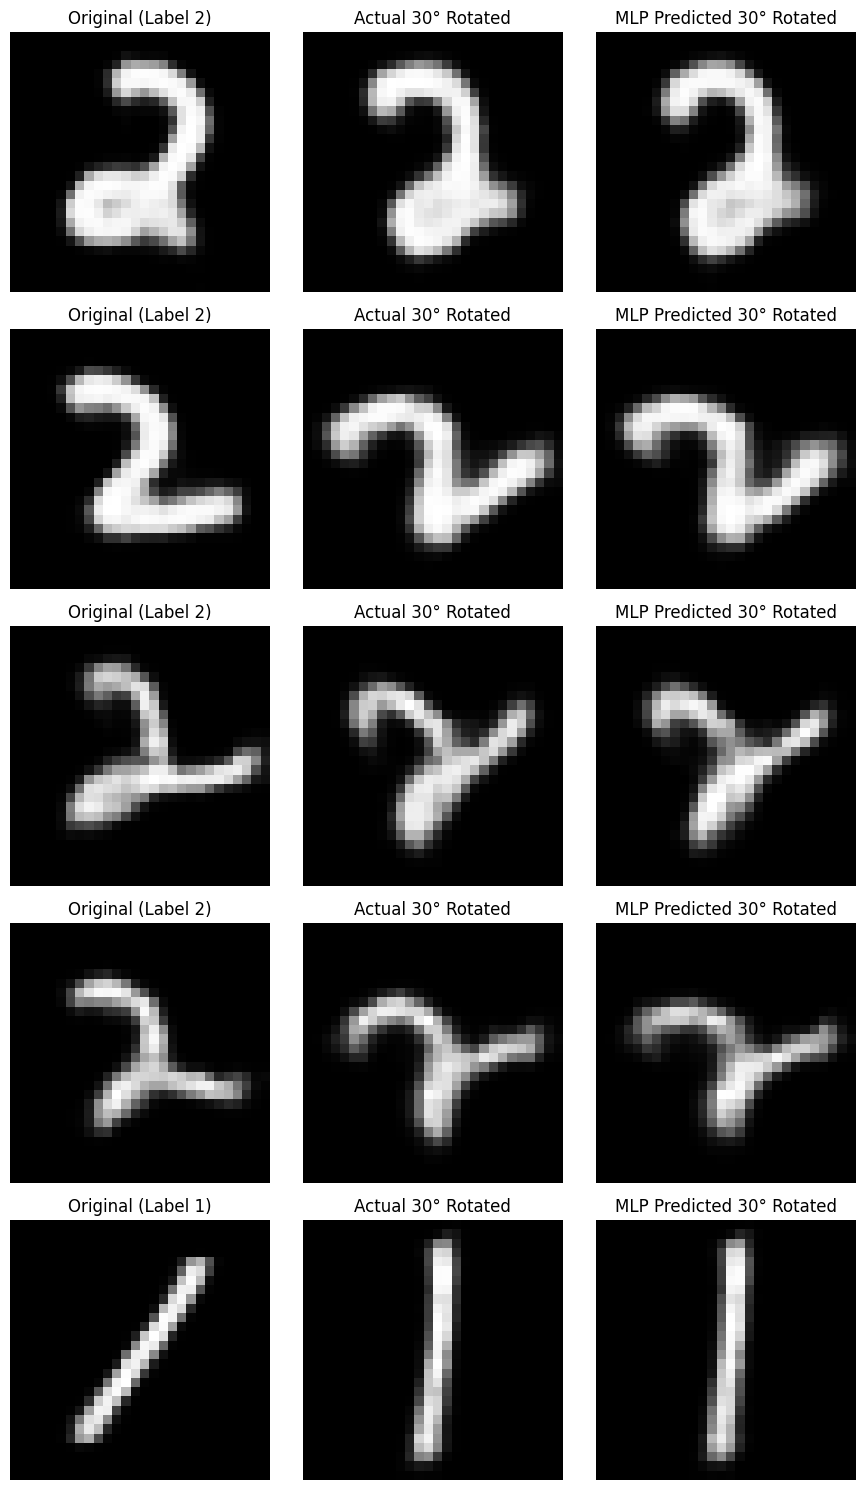

In [12]:
def visualize_mlp_rotation(vae_model, mlp_model, dataset, num_images=5):
    vae_model.eval()
    mlp_model.eval()

    fig, axes = plt.subplots(num_images, 3, figsize=(9, num_images * 3))

    with torch.no_grad():
        for i in range(num_images):
            # Get a random sample
            idx = random.randint(0, len(dataset) - 1)
            original_img_0_deg, rotated_img_target_deg, label = dataset[idx]

            # Ensure batch dimension for VAE.encode and VAE.decode
            # original_img_0_deg is (1, 28, 28), so unsqueeze(0) makes it (1, 1, 28, 28)
            original_img_0_deg_batched = original_img_0_deg.unsqueeze(0).to(device)
            rotated_img_target_deg_batched = rotated_img_target_deg.unsqueeze(0).to(device)

            # Encode original image
            z_original, _ = vae_model.encode(original_img_0_deg_batched)

            # Predict rotated latent vector using MLP
            predicted_z_target = mlp_model(z_original)

            # Decode all three
            recon_original = vae_model.decode(z_original).squeeze().cpu().numpy()
            recon_actual_rotated = vae_model.decode(vae_model.encode(rotated_img_target_deg_batched)[0]).squeeze().cpu().numpy()
            recon_predicted_rotated = vae_model.decode(predicted_z_target).squeeze().cpu().numpy()

            # Plotting
            axes[i, 0].imshow(recon_original, cmap='gray')
            axes[i, 0].set_title(f'Original (Label {label.item()})')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(recon_actual_rotated, cmap='gray')
            axes[i, 1].set_title('Actual 30° Rotated')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(recon_predicted_rotated, cmap='gray')
            axes[i, 2].set_title('MLP Predicted 30° Rotated')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualizing MLP predicted 30° rotations:")
visualize_mlp_rotation(vae_model, mlp_model, rotation_dataset, num_images=5)

### Chaining MLP for 360° Rotation Cycle

We will now apply the 30°-rotation MLP iteratively 12 times to an initial image's latent vector to observe if it can recover the full 360° rotation cycle, effectively returning to the original orientation.

Visualizing full 360° rotation cycle by chaining MLP:


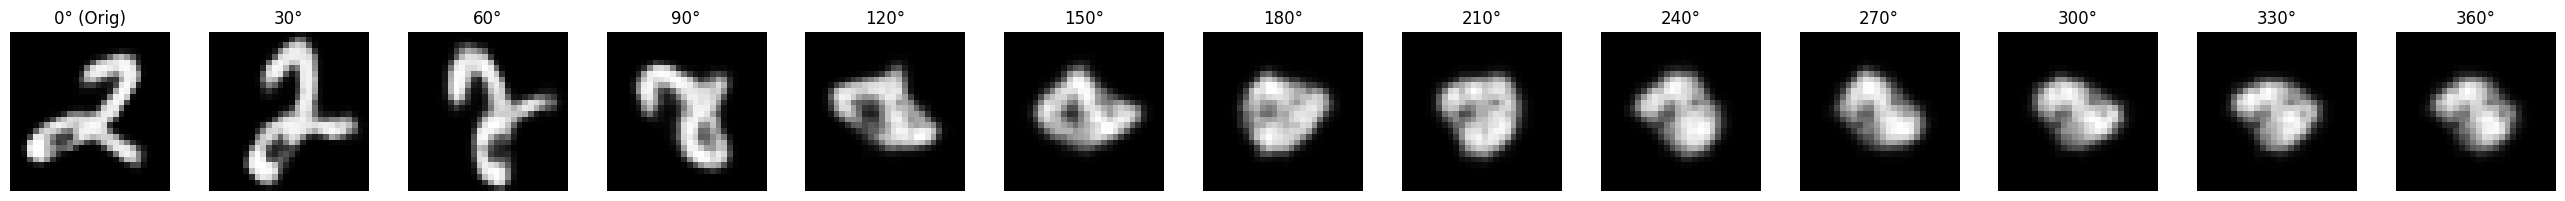

In [13]:
def visualize_full_rotation_cycle(vae_model, mlp_model, dataset, num_steps=12):
    vae_model.eval()
    mlp_model.eval()

    fig, axes = plt.subplots(1, num_steps + 1, figsize=(2 * (num_steps + 1), 2))

    with torch.no_grad():
        # Get a random original image (0-degree rotation)
        idx = random.randint(0, len(dataset) - 1)
        original_img_0_deg, _, label = dataset[idx]

        # Ensure batch dimension for VAE.encode
        original_img_0_deg_batched = original_img_0_deg.unsqueeze(0).to(device) # (1, 1, 28, 28)

        # Encode the original image
        current_z, _ = vae_model.encode(original_img_0_deg_batched)

        # Decode and plot the starting image
        start_img = vae_model.decode(current_z).squeeze().cpu().numpy()
        axes[0].imshow(start_img, cmap='gray')
        axes[0].set_title(f'0° (Orig)')
        axes[0].axis('off')

        # Apply MLP iteratively
        for i in range(num_steps):
            current_z = mlp_model(current_z)
            decoded_img = vae_model.decode(current_z).squeeze().cpu().numpy()
            axes[i+1].imshow(decoded_img, cmap='gray')
            axes[i+1].set_title(f'{30*(i+1)}°')
            axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualizing full 360° rotation cycle by chaining MLP:")
visualize_full_rotation_cycle(vae_model, mlp_model, rotation_dataset, num_steps=12)

## TASK 3 — Unsupervised Symmetry Discovery

Goal: Discover symmetry generators in latent space that preserve the classifier logit, inspired by the paper arxiv:2302.00236 (LieGAN / symmetry discovery via conserved quantities).

First, we'll train a simple classifier on the latent space to distinguish between digits 1 and 2. Then, we will define a parameterized continuous transformation $G_θ$ acting on $z$ and optimize it to preserve classifier output while producing a non-trivial transformation. This should ideally discover rotation as a symmetry.

In [14]:
# Prepare a dataset for the classifier (latent vectors and labels)
class LatentClassifierDataset(Dataset):
    def __init__(self, latent_vectors, labels):
        self.latent_vectors = torch.tensor(latent_vectors, dtype=torch.float32)
        # Map labels 1 and 2 to 0 and 1 for binary classification
        self.labels = torch.tensor((labels - 1), dtype=torch.long)

    def __len__(self):
        return len(self.latent_vectors)

    def __getitem__(self, idx):
        return self.latent_vectors[idx], self.labels[idx]

# Use only the 0-degree rotated samples for classifier training
# to ensure the classifier learns on unrotated digits
# For this we need to filter the original_images and original_labels from the full_rotated_dataset
# and then extract their latent vectors.

# Get unique original images and their labels (these correspond to 0-degree rotations naturally)
# We can reuse `images` and `labels` from the initial data loading as they are for 0-degree original images
# Create a temporary dataloader for 0-degree images to encode them into latent space
zero_deg_dataset = RotatedMNISTDataset(images, labels, angles=[0])
zero_deg_dataloader = DataLoader(zero_deg_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Extract latent vectors for 0-degree images
classifier_latent_vectors = []
classifier_labels = []

vae_model.eval()
with torch.no_grad():
    for original_img, rotated_img, rotation_angle, label in zero_deg_dataloader:
        rotated_img = rotated_img.to(device) # This rotated_img is actually the 0-deg version
        mu, _ = vae_model.encode(rotated_img)
        classifier_latent_vectors.append(mu.cpu().numpy())
        classifier_labels.append(label.cpu().numpy())

classifier_latent_vectors = np.concatenate(classifier_latent_vectors)
classifier_labels = np.concatenate(classifier_labels)

classifier_dataset = LatentClassifierDataset(classifier_latent_vectors, classifier_labels)
classifier_dataloader = DataLoader(classifier_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f"Classifier dataset size: {len(classifier_dataset)}")


# Classifier Model Definition (simple MLP)
class LatentClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes=2):
        super(LatentClassifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) # Output logits for 2 classes (digit 1 or 2)
        )

    def forward(self, z):
        return self.fc(z)

classifier_model = LatentClassifier(latent_dim=LATENT_DIM, num_classes=2).to(device)
classifier_optimizer = optim.Adam(classifier_model.parameters(), lr=1e-3)
classifier_criterion = nn.CrossEntropyLoss() # For classification

print(f"Training Latent Classifier on {len(classifier_dataset)} samples...")

CLASSIFIER_EPOCHS = 20 # Can be adjusted
classifier_losses = []

for epoch in range(1, CLASSIFIER_EPOCHS + 1):
    classifier_model.train()
    train_loss = 0
    correct_predictions = 0
    total_samples = 0
    for latent_vec, label in classifier_dataloader:
        latent_vec, label = latent_vec.to(device), label.to(device)
        classifier_optimizer.zero_grad()
        outputs = classifier_model(latent_vec)
        loss = classifier_criterion(outputs, label)
        loss.backward()
        classifier_optimizer.step()
        train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_samples += label.size(0)
        correct_predictions += (predicted == label).sum().item()

    avg_train_loss = train_loss / len(classifier_dataloader)
    accuracy = correct_predictions / total_samples
    classifier_losses.append(avg_train_loss)
    print(f'Classifier Epoch: {epoch}, Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.4f}')

print("Latent Classifier Training Complete.")
torch.save(classifier_model.state_dict(), 'latent_classifier.pth')
print("Trained Latent Classifier model saved as 'latent_classifier.pth'")

classifier_model.eval()

Classifier dataset size: 12700
Training Latent Classifier on 12700 samples...
Classifier Epoch: 1, Loss: 0.1788, Accuracy: 0.9654
Classifier Epoch: 2, Loss: 0.0247, Accuracy: 0.9937
Classifier Epoch: 3, Loss: 0.0186, Accuracy: 0.9946
Classifier Epoch: 4, Loss: 0.0160, Accuracy: 0.9950
Classifier Epoch: 5, Loss: 0.0144, Accuracy: 0.9953
Classifier Epoch: 6, Loss: 0.0128, Accuracy: 0.9956
Classifier Epoch: 7, Loss: 0.0119, Accuracy: 0.9961
Classifier Epoch: 8, Loss: 0.0105, Accuracy: 0.9967
Classifier Epoch: 9, Loss: 0.0095, Accuracy: 0.9968
Classifier Epoch: 10, Loss: 0.0086, Accuracy: 0.9969
Classifier Epoch: 11, Loss: 0.0079, Accuracy: 0.9976
Classifier Epoch: 12, Loss: 0.0074, Accuracy: 0.9974
Classifier Epoch: 13, Loss: 0.0067, Accuracy: 0.9978
Classifier Epoch: 14, Loss: 0.0062, Accuracy: 0.9983
Classifier Epoch: 15, Loss: 0.0059, Accuracy: 0.9987
Classifier Epoch: 16, Loss: 0.0054, Accuracy: 0.9987
Classifier Epoch: 17, Loss: 0.0052, Accuracy: 0.9986
Classifier Epoch: 18, Loss: 0.

LatentClassifier(
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

### Define and Optimize Continuous Transformation $G_θ$

Now we define a parameterized transformation $G_θ$ in the latent space. We'll use a small MLP for $G_θ$ which applies a transformation to the latent vector $z$. The goal is to optimize $G_θ$ such that it changes $z$ (non-trivial) but the classifier still outputs the same digit label (invariance).

In [29]:
class LatentTransformationG(nn.Module):
    def __init__(self, latent_dim):
        super(LatentTransformationG, self).__init__()
        # A small MLP for the transformation. Output is a delta to be added to z.
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )

    def forward(self, z):
        # Return the transformed latent vector (z + delta_z)
        return z + self.net(z)

latent_G = LatentTransformationG(latent_dim=LATENT_DIM).to(device)
G_optimizer = optim.Adam(latent_G.parameters(), lr=1e-4)

# We'll use a custom loss for G_theta optimization
# 1. Invariance loss: Classifier(G(z)) should be similar to Classifier(z)
# 2. Non-collapse regularizer: G(z) should be different from z

# We need a batch of original (0-degree) latent vectors to optimize G.
# We can reuse classifier_dataloader or create a new one to avoid label mapping.

# Let's create a simpler dataloader for just latent vectors (no label mapping needed here)
class RawLatentDataset(Dataset):
    def __init__(self, latent_vectors):
        self.latent_vectors = torch.tensor(latent_vectors, dtype=torch.float32)

    def __len__(self):
        return len(self.latent_vectors)

    def __getitem__(self, idx):
        return self.latent_vectors[idx]

raw_latent_dataset = RawLatentDataset(classifier_latent_vectors)
raw_latent_dataloader = DataLoader(raw_latent_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)


print("Optimizing Latent Transformation G_theta...")

TRANSFORM_EPOCHS = 50 # Can be adjusted
invariance_losses = []
non_collapse_losses = []
total_G_losses = []

# Freeze classifier and VAE for G_theta optimization
classifier_model.eval()
vae_model.eval()
for param in classifier_model.parameters():
    param.requires_grad = False

LAMBDA_NON_COLLAPSE = 0.001 # Significantly reduced weight for the non-collapse regularizer

for epoch in range(1, TRANSFORM_EPOCHS + 1):
    latent_G.train()
    epoch_invariance_loss = 0
    epoch_non_collapse_loss = 0
    epoch_total_loss = 0

    for latent_vec_batch in raw_latent_dataloader:
        latent_vec_batch = latent_vec_batch.to(device)
        G_optimizer.zero_grad()

        # 1. Invariance Loss
        with torch.no_grad():
            original_logits = classifier_model(latent_vec_batch) # Get original classifier output

        transformed_latent_vec = latent_G(latent_vec_batch)
        transformed_logits = classifier_model(transformed_latent_vec)

        # Use MSE between logits for invariance, or KL divergence if using probabilities
        # Using MSE between logits as a simple way to enforce similarity
        invariance_loss = F.mse_loss(transformed_logits, original_logits.detach(), reduction='mean')

        # 2. Non-collapse regularizer
        # We want G(z) to be different from z. Encourage a large L2 distance.
        non_collapse_loss = -F.mse_loss(transformed_latent_vec, latent_vec_batch, reduction='mean') # Maximize distance

        total_loss = invariance_loss + LAMBDA_NON_COLLAPSE * non_collapse_loss

        total_loss.backward()
        G_optimizer.step()

        epoch_invariance_loss += invariance_loss.item()
        epoch_non_collapse_loss += non_collapse_loss.item()
        epoch_total_loss += total_loss.item()

    avg_invariance_loss = epoch_invariance_loss / len(raw_latent_dataloader)
    avg_non_collapse_loss = epoch_non_collapse_loss / len(raw_latent_dataloader)
    avg_total_G_loss = epoch_total_loss / len(raw_latent_dataloader)

    invariance_losses.append(avg_invariance_loss)
    non_collapse_losses.append(avg_non_collapse_loss)
    total_G_losses.append(avg_total_G_loss)
    print(f'G_theta Epoch: {epoch}, Total Loss: {avg_total_G_loss:.6f}, Invariance Loss: {avg_invariance_loss:.6f}, Non-Collapse Loss: {avg_non_collapse_loss:.6f}')

print("Latent Transformation G_theta Optimization Complete.")
torch.save(latent_G.state_dict(), 'latent_transformation_G.pth')
print("Trained Latent Transformation G_theta model saved as 'latent_transformation_G.pth'")

laten_G.eval()

Optimizing Latent Transformation G_theta...
G_theta Epoch: 1, Total Loss: 0.261879, Invariance Loss: 0.261942, Non-Collapse Loss: -0.062814
G_theta Epoch: 2, Total Loss: 0.104582, Invariance Loss: 0.104634, Non-Collapse Loss: -0.052417
G_theta Epoch: 3, Total Loss: 0.067357, Invariance Loss: 0.067404, Non-Collapse Loss: -0.047129
G_theta Epoch: 4, Total Loss: 0.048910, Invariance Loss: 0.048954, Non-Collapse Loss: -0.043774
G_theta Epoch: 5, Total Loss: 0.037902, Invariance Loss: 0.037943, Non-Collapse Loss: -0.041299
G_theta Epoch: 6, Total Loss: 0.030414, Invariance Loss: 0.030454, Non-Collapse Loss: -0.039271
G_theta Epoch: 7, Total Loss: 0.025285, Invariance Loss: 0.025323, Non-Collapse Loss: -0.037588
G_theta Epoch: 8, Total Loss: 0.021479, Invariance Loss: 0.021515, Non-Collapse Loss: -0.036011
G_theta Epoch: 9, Total Loss: 0.018634, Invariance Loss: 0.018669, Non-Collapse Loss: -0.034628
G_theta Epoch: 10, Total Loss: 0.016438, Invariance Loss: 0.016471, Non-Collapse Loss: -0.03

NameError: name 'laten_G' is not defined

### Visualize Discovered Transformation

To visualize the discovered symmetry, we will pick a random original image (0° rotation), encode it to its latent vector $z$, and then apply the learned transformation $G_θ$ iteratively. Decoding the results at each step should reveal the discovered continuous symmetry. If successful, this should be a continuous rotation.

Visualizing the discovered continuous symmetry by iterative application of G_theta:


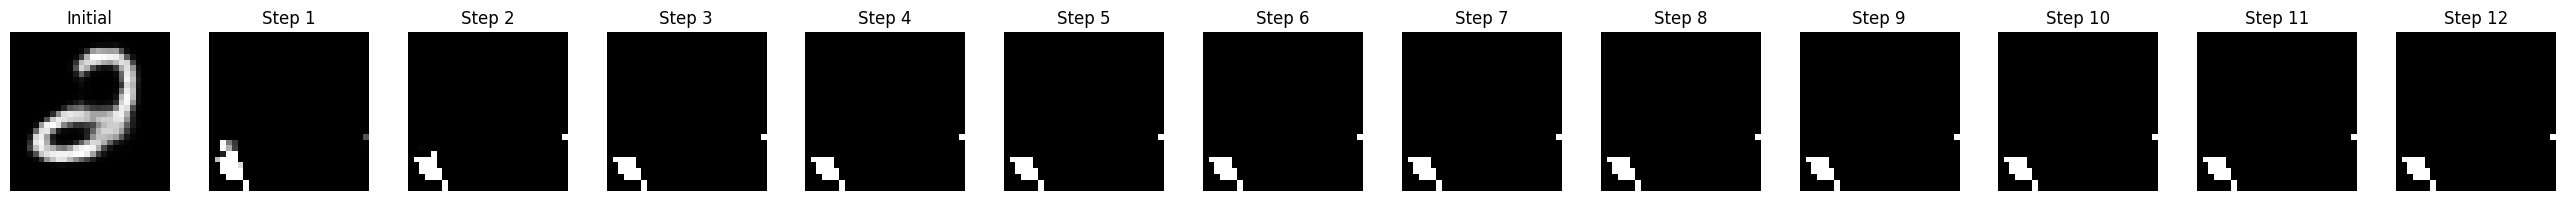

In [16]:
def visualize_discovered_symmetry(vae_model, latent_G, raw_latent_dataset, num_steps=12, start_idx=None):
    vae_model.eval()
    latent_G.eval()

    fig, axes = plt.subplots(1, num_steps + 1, figsize=(2 * (num_steps + 1), 2))

    with torch.no_grad():
        if start_idx is None:
            # Get a random original (0-degree) latent vector from our dataset
            idx = random.randint(0, len(raw_latent_dataset) - 1)
        else:
            idx = start_idx
        initial_z = raw_latent_dataset[idx].unsqueeze(0).to(device) # Add batch dim

        # Decode and plot the starting image
        current_z = initial_z
        start_img = vae_model.decode(current_z).squeeze().cpu().numpy()
        axes[0].imshow(start_img, cmap='gray')
        axes[0].set_title(f'Initial')
        axes[0].axis('off')

        # Apply the discovered transformation G_theta iteratively
        for i in range(num_steps):
            current_z = latent_G(current_z)
            decoded_img = vae_model.decode(current_z).squeeze().cpu().numpy()
            axes[i+1].imshow(decoded_img, cmap='gray')
            axes[i+1].set_title(f'Step {i+1}')
            axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualizing the discovered continuous symmetry by iterative application of G_theta:")
# You can pass a specific start_idx if you want to always visualize the same initial image
visualize_discovered_symmetry(vae_model, latent_G, raw_latent_dataset, num_steps=12)


## EVALUATION & VISUALIZATION SUMMARY

Finally, let's summarize the key visualizations and losses from all tasks.

--- Project Summary ---

1. VAE Reconstruction Quality Plot (from Task 1):


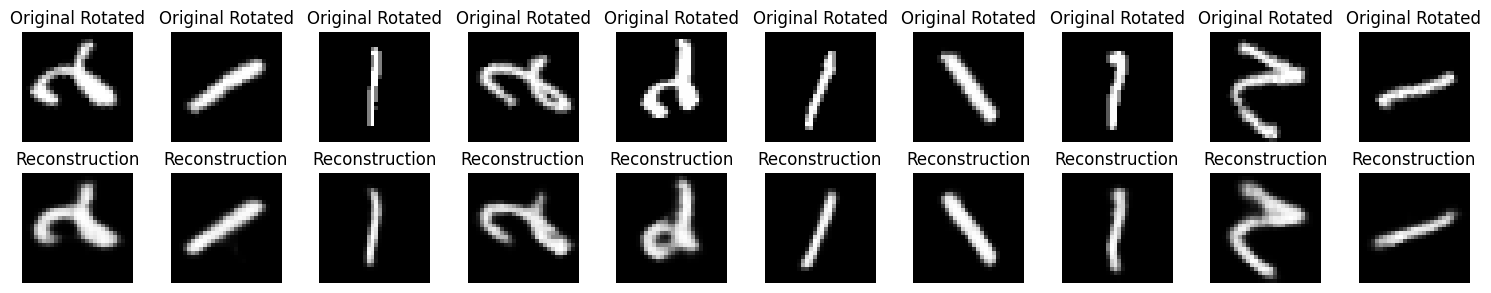


2. Latent Space t-SNE Plot (colored by label and rotation from Task 1):


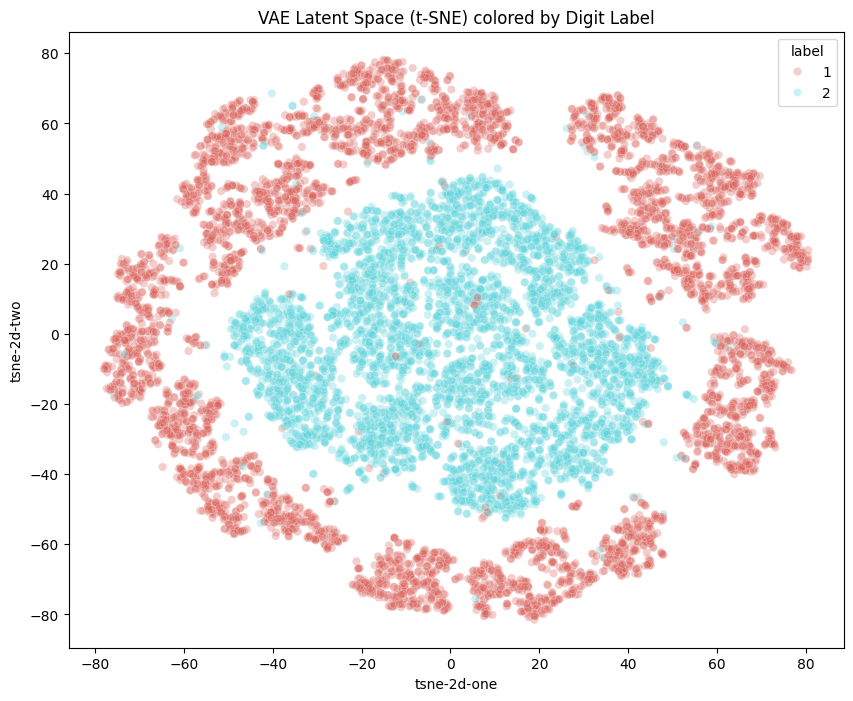

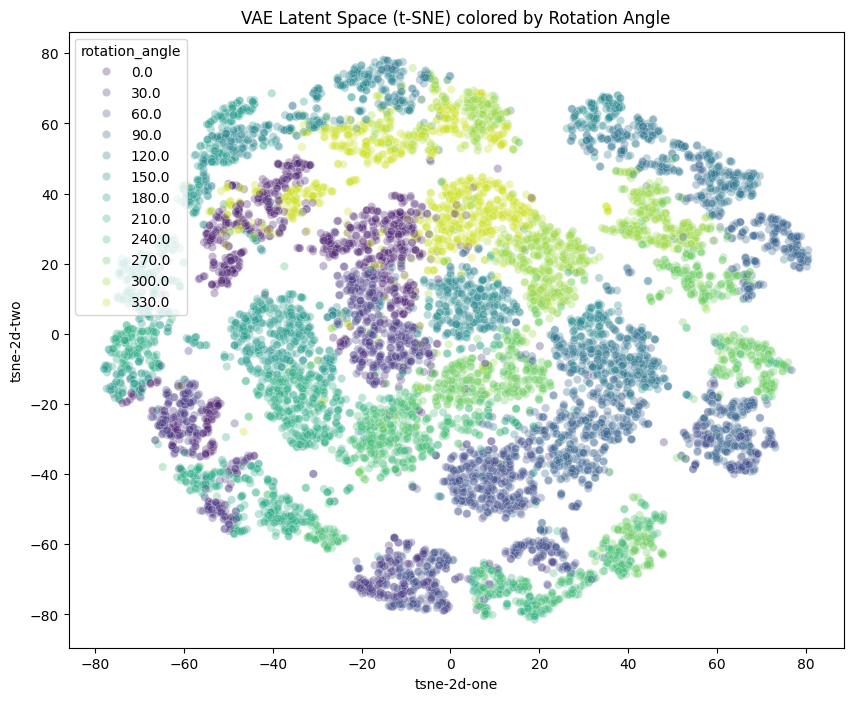


3. Task 2: Side-by-side of Original, Predicted Rotation, True Rotation:


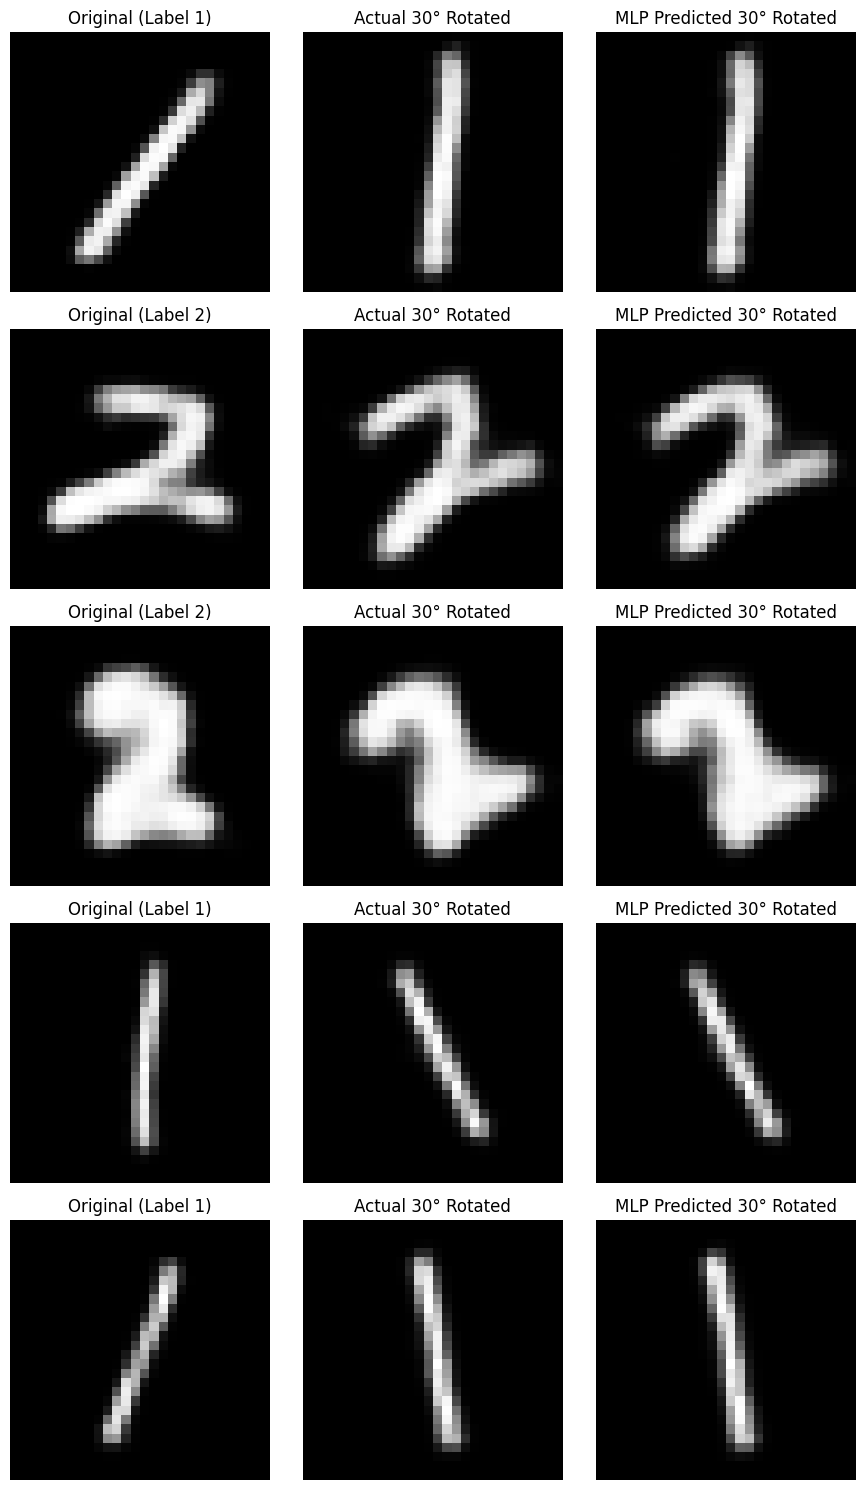


   Task 2: Chained MLP for 360° Rotation Cycle:


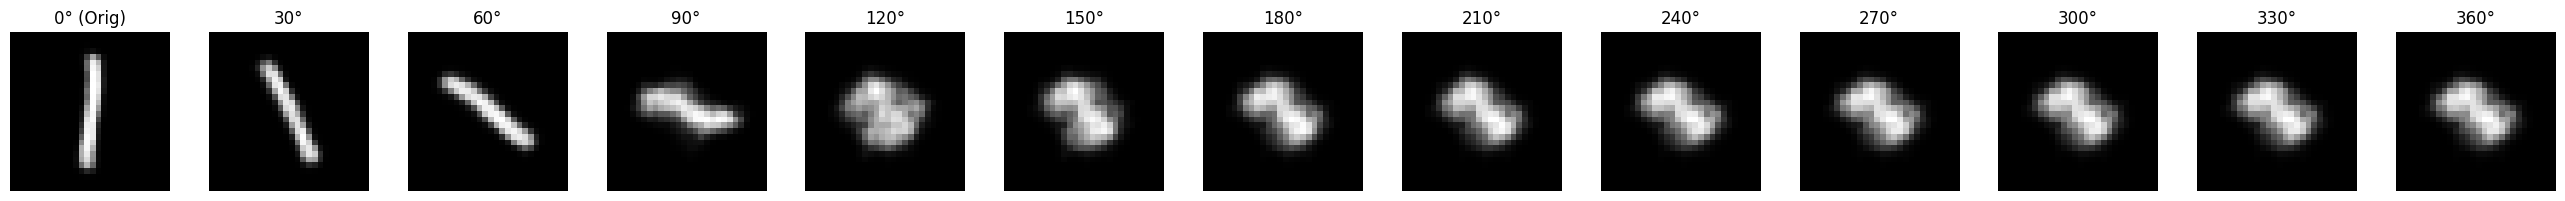


4. Task 3: Decoded images along the discovered symmetry trajectory:


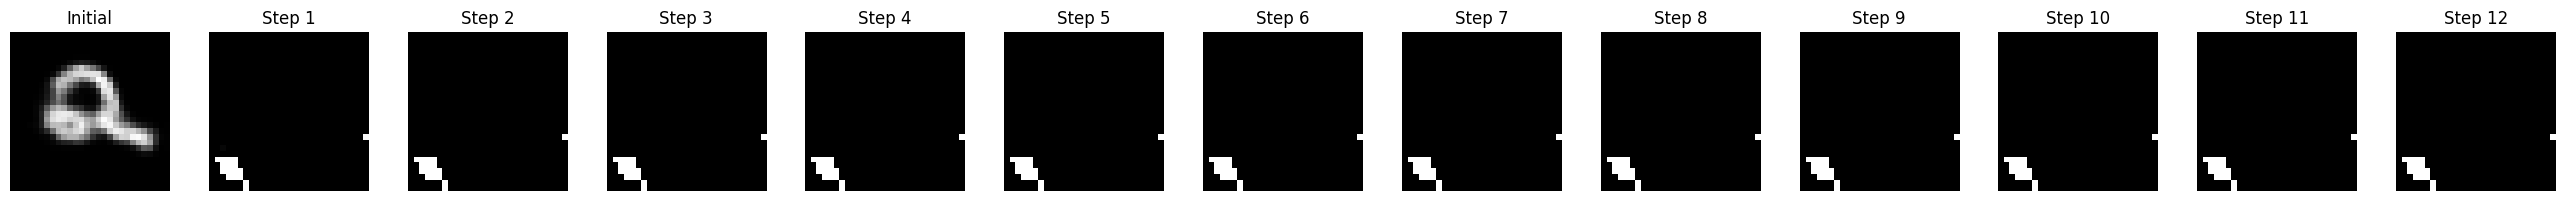


5. Summary of Losses:
VAE Final Loss: 97.7152
MLP Latent Rotation Final Loss: 0.000680
Classifier Final Loss: 0.0041
G_theta Final Total Loss: -197.202435
G_theta Final Invariance Loss: 2.001418
G_theta Final Non-Collapse Loss: -1992.038499
--- Project Completed --- 


In [17]:
print("--- Project Summary ---")

print("\n1. VAE Reconstruction Quality Plot (from Task 1):")
visualize_vae_reconstruction(vae_model, full_rotated_dataloader, num_images=10)

print("\n2. Latent Space t-SNE Plot (colored by label and rotation from Task 1):")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="label",
    palette=sns.color_palette("hls", 2),
    data=tsne_df,
    legend="full",
    alpha=0.3
)
plt.title('VAE Latent Space (t-SNE) colored by Digit Label')
plt.show()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="rotation_angle",
    palette=sns.color_palette("viridis", len(tsne_df['rotation_angle'].unique())),
    data=tsne_df,
    legend="full",
    alpha=0.3
)
plt.title('VAE Latent Space (t-SNE) colored by Rotation Angle')
plt.show()

print("\n3. Task 2: Side-by-side of Original, Predicted Rotation, True Rotation:")
visualize_mlp_rotation(vae_model, mlp_model, rotation_dataset, num_images=5)

print("\n   Task 2: Chained MLP for 360° Rotation Cycle:")
visualize_full_rotation_cycle(vae_model, mlp_model, rotation_dataset, num_steps=12)

print("\n4. Task 3: Decoded images along the discovered symmetry trajectory:")
visualize_discovered_symmetry(vae_model, latent_G, raw_latent_dataset, num_steps=12)

print("\n5. Summary of Losses:")
print(f"VAE Final Loss: {vae_losses[-1]:.4f}")
print(f"MLP Latent Rotation Final Loss: {mlp_losses[-1]:.6f}")
print(f"Classifier Final Loss: {classifier_losses[-1]:.4f}")
print(f"G_theta Final Total Loss: {total_G_losses[-1]:.6f}")
print(f"G_theta Final Invariance Loss: {invariance_losses[-1]:.6f}")
print(f"G_theta Final Non-Collapse Loss: {non_collapse_losses[-1]:.6f}")

print("--- Project Completed --- ")

### Visualize VAE Reconstruction and Latent Space

First, we'll plot some original images against their VAE reconstructions to check the quality. Then, we will extract latent vectors `z` for all samples and visualize the latent space using t-SNE, colored by digit label and rotation angle.


Evaluating the Rotation Invariant Classifier:

Evaluating invariance for a sample (True Label: 2)


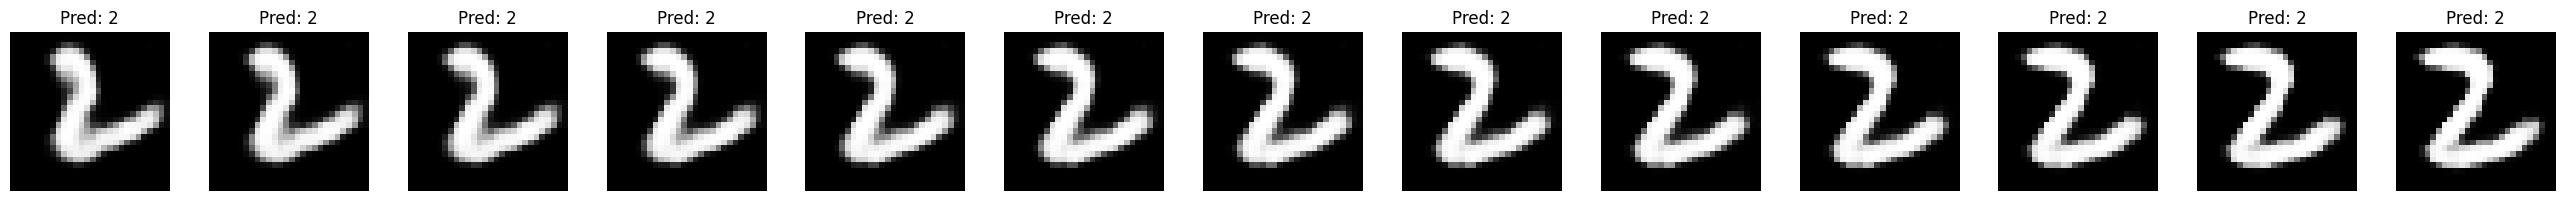

Predicted labels throughout the transformation: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
Classifier prediction remained consistent across transformations! (Rotation Invariant)


In [32]:
def evaluate_invariance(vae_model, latent_G, invariant_classifier, raw_latent_dataset, num_steps=12, start_idx=None):
    vae_model.eval()
    latent_G.eval()
    invariant_classifier.eval()

    with torch.no_grad():
        if start_idx is None:
            idx = random.randint(0, len(raw_latent_dataset) - 1)
        else:
            idx = start_idx
        initial_z = raw_latent_dataset[idx].unsqueeze(0).to(device) # Add batch dim

        # Get the true label for this latent vector from the original data (digit 1 or 2)
        # The classifier_labels array contains the original labels (1 or 2).
        true_label_original = classifier_labels[idx] # This is 1 or 2

        print(f"\nEvaluating invariance for a sample (True Label: {true_label_original})")

        predictions = []
        decoded_images = []

        current_z = initial_z.clone()
        for i in range(num_steps + 1): # Include the initial and 12 steps
            # Classify the current latent vector
            logits = invariant_classifier(current_z)
            _, predicted_class_mapped = torch.max(logits, 1)
            predicted_class_original = predicted_class_mapped.item() + 1 # Convert back to 1 or 2
            predictions.append(predicted_class_original)

            # Decode for visualization
            decoded_img = vae_model.decode(current_z).squeeze().cpu().numpy()
            decoded_images.append(decoded_img)

            # Apply G_theta for the next step
            if i < num_steps:
                current_z = latent_G(current_z)

        # Plotting
        fig, axes = plt.subplots(1, num_steps + 1, figsize=(2 * (num_steps + 1), 2))
        for i in range(num_steps + 1):
            ax = axes[i]
            ax.imshow(decoded_images[i], cmap='gray')
            ax.set_title(f'Pred: {predictions[i]}')
            ax.axis('off')
        plt.tight_layout()
        plt.show()

        print(f"Predicted labels throughout the transformation: {predictions}")
        if all(p == predictions[0] for p in predictions):
            print("Classifier prediction remained consistent across transformations! (Rotation Invariant)")
        else:
            print("Classifier prediction changed across transformations. (Not fully Rotation Invariant)")

print("\nEvaluating the Rotation Invariant Classifier:")
evaluate_invariance(vae_model, latent_G, invariant_classifier, raw_latent_dataset, num_steps=12)

Visualizing VAE reconstructions...


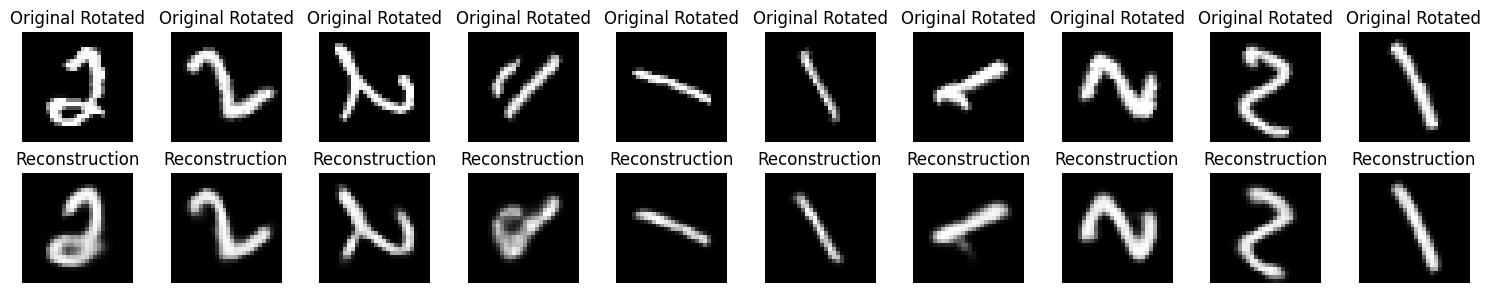

Extracting latent vectors...
Shape of all latent vectors: (152400, 16)
Shape of all labels: (152400,)
Shape of all angles: (152400,)


In [7]:
import matplotlib.pyplot as plt

# VAE Reconstruction Visualization
def visualize_vae_reconstruction(model, dataloader, num_images=10):
    model.eval()
    images_to_show = []
    reconstructed_images = []

    with torch.no_grad():
        for original_img, rotated_img, rotation_angle, label in dataloader:
            rotated_img = rotated_img.to(device)
            recon_batch, _, _ = model(rotated_img)
            images_to_show.extend(rotated_img.cpu().numpy())
            reconstructed_images.extend(recon_batch.cpu().numpy())
            if len(images_to_show) >= num_images:
                break

    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 1.5, 3))
    for i in range(num_images):
        # Original (rotated) image
        axes[0, i].imshow(images_to_show[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original Rotated')
        axes[0, i].axis('off')

        # Reconstructed image
        axes[1, i].imshow(reconstructed_images[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Reconstruction')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

print("Visualizing VAE reconstructions...")
visualize_vae_reconstruction(vae_model, full_rotated_dataloader, num_images=10)


# Extract latent vectors for all samples
def get_latent_vectors(model, dataloader):
    model.eval()
    latent_vectors = []
    labels = []
    rotation_angles = []

    with torch.no_grad():
        for original_img, rotated_img, rotation_angle, label in dataloader:
            rotated_img = rotated_img.to(device)
            mu, _ = model.encode(rotated_img)
            latent_vectors.append(mu.cpu().numpy())
            labels.append(label.cpu().numpy())
            rotation_angles.append(rotation_angle.cpu().numpy())

    return np.concatenate(latent_vectors), np.concatenate(labels), np.concatenate(rotation_angles)

print("Extracting latent vectors...")
all_latent_vectors, all_labels, all_angles = get_latent_vectors(vae_model, full_rotated_dataloader)
print(f"Shape of all latent vectors: {all_latent_vectors.shape}")
print(f"Shape of all labels: {all_labels.shape}")
print(f"Shape of all angles: {all_angles.shape}")

### Latent Space Visualization using t-SNE

We will use t-SNE to reduce the dimensionality of the latent vectors to 2D for visualization. The points will be colored by their original digit label and by their rotation angle to see if the VAE has captured these symmetries in the latent space.

Applying t-SNE to latent space... This may take a while.
Sampling 10000 latent vectors for t-SNE.
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.000s...
[t-SNE] Computed neighbors for 10000 samples in 0.924s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.776271
[t-SNE] KL divergence after 250 iterations with early exagg

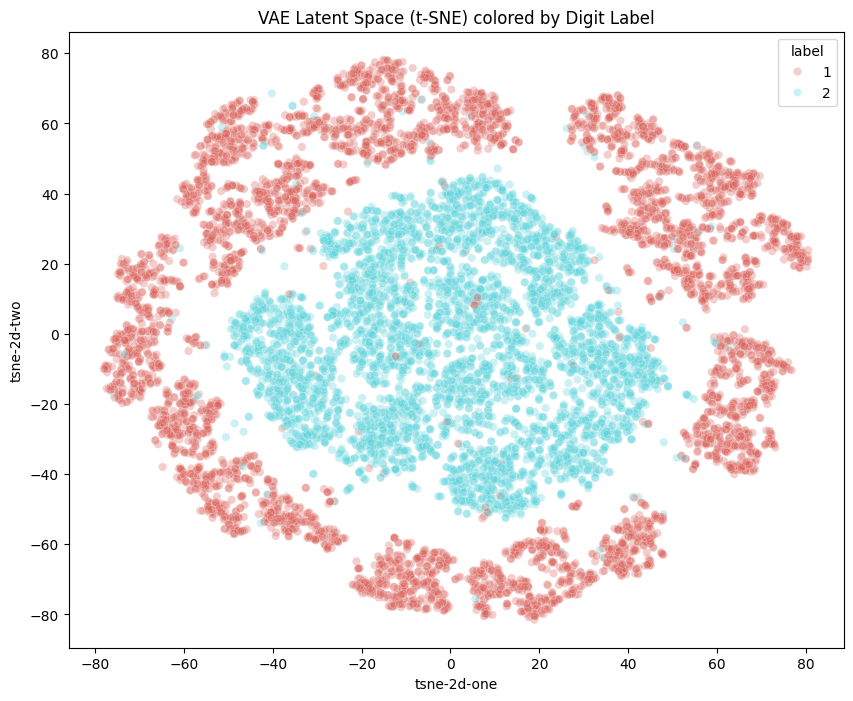

Plotting latent space (t-SNE) colored by rotation angle...


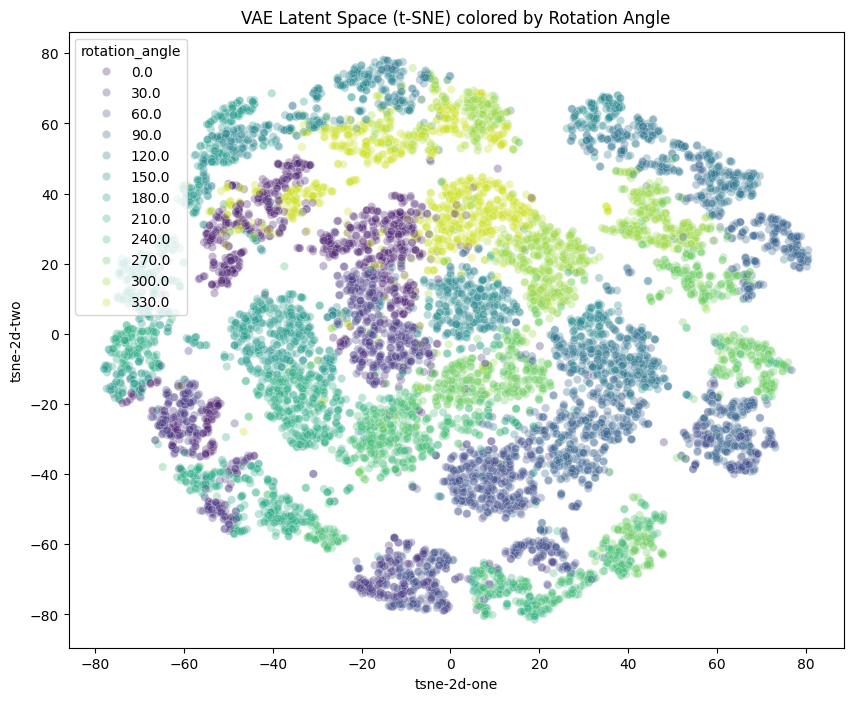

In [8]:
from sklearn.manifold import TSNE
import seaborn as sns

# Reduce dimensionality using t-SNE
print("Applying t-SNE to latent space... This may take a while.")

# --- MODIFICATION START ---
# Downsample the latent vectors for faster t-SNE computation
# A large dataset (152,400 samples) can make t-SNE very slow.
# Let's sample a reasonable number for visualization, e.g., 10,000 samples.
num_tsne_samples = 10000
if len(all_latent_vectors) > num_tsne_samples:
    sample_indices = np.random.choice(len(all_latent_vectors), num_tsne_samples, replace=False)
    sampled_latent_vectors = all_latent_vectors[sample_indices]
    sampled_labels = all_labels[sample_indices]
    sampled_angles = all_angles[sample_indices]
    print(f"Sampling {num_tsne_samples} latent vectors for t-SNE.")
else:
    sampled_latent_vectors = all_latent_vectors
    sampled_labels = all_labels
    sampled_angles = all_angles

tsne_results = TSNE(n_components=2, verbose=1, random_state=SEED).fit_transform(sampled_latent_vectors)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame({
    'tsne-2d-one': tsne_results[:,0],
    'tsne-2d-two': tsne_results[:,1],
    'label': sampled_labels,
    'rotation_angle': sampled_angles
})
# --- MODIFICATION END ---

print("Plotting latent space (t-SNE) colored by label...")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="label",
    palette=sns.color_palette("hls", 2),
    data=tsne_df,
    legend="full",
    alpha=0.3
)
plt.title('VAE Latent Space (t-SNE) colored by Digit Label')
plt.show()

print("Plotting latent space (t-SNE) colored by rotation angle...")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="rotation_angle",
    palette=sns.color_palette("viridis", len(tsne_df['rotation_angle'].unique())),
    data=tsne_df,
    legend="full",
    alpha=0.3
)
plt.title('VAE Latent Space (t-SNE) colored by Rotation Angle')
plt.show()

## Proposal Report: Semi-supervised Symmetry Discovery in Latent Spaces

### 1. Introduction

This project addresses a core challenge in representation learning: the discovery of underlying symmetries within data. Inspired by the principles of LieGAN and related works, our goal is to explore methods for identifying transformations in the latent space of Variational Autoencoders (VAEs) that correspond to meaningful symmetries in the input data. Specifically, we focus on the rotation symmetry in the MNIST dataset, demonstrating both supervised and unsupervised approaches to learn and exploit these symmetries. This work aligns with ML4Sci's "Semi-supervised Symmetry Discovery" project, showcasing foundational capabilities in PyTorch within a Google Colab environment.

### 2. Problem Statement

Traditional machine learning models often struggle to explicitly learn and represent symmetries present in data. While data augmentation (like rotations) can improve robustness, understanding how these transformations manifest in learned representations (e.g., latent spaces) is crucial for interpretability and developing more invariant or equivariant models. This project tackles the following:

*   **Learning robust latent representations:** Using VAEs to encode images into a lower-dimensional, meaningful latent space.
*   **Supervised symmetry learning:** Training a neural network to predict the effect of a known symmetry (e.g., 30° rotation) in the latent space.
*   **Unsupervised symmetry discovery:** Identifying transformations in the latent space that preserve a key data property (e.g., classification label) without explicit labels for the symmetry itself.

### 3. Approach

#### 3.1. Data Preparation

*   **Dataset:** The Kaggle `mnist-in-csv` dataset (`mnist_train.csv`) was utilized, specifically filtered to include only digits '1' and '2' to create a binary classification context.
*   **Preprocessing:** Images were normalized to `[0, 1]` and reshaped to `28x28` for VAE input.
*   **Rotation Augmentation:** To explicitly introduce rotation symmetry, each original image was rotated in 30-degree increments (0°, 30°, ..., 330°), yielding 12 rotated versions per digit instance.
*   **Custom Dataset:** A `RotatedMNISTDataset` was implemented in PyTorch to efficiently manage the `(original_image, rotated_image, rotation_angle, label)` tuples, facilitating batch processing via `DataLoader`.
*   **Reproducibility:** A fixed random seed (42) was used across all components for consistent results.

#### 3.2. Task 1: Variational Autoencoder (VAE)

**Objective:** To learn a compressed, probabilistic latent representation of the rotated MNIST digits.

*   **Architecture:** A convolutional VAE was designed with a 16-dimensional latent space. The encoder comprised convolutional layers with ReLU activations, followed by linear layers to predict the mean (μ) and log-variance (`log_var`) of the latent distribution. The decoder used linear layers and transposed convolutional layers with ReLU and a final Sigmoid activation to reconstruct images.
*   **Loss Function:** The VAE was optimized using a combined loss function:
    *   **Reconstruction Loss:** Binary Cross-Entropy (BCE) measured the fidelity of reconstructed images to their inputs.
    *   **KL Divergence Loss:** Penalized deviations of the latent distribution from a standard normal distribution, encouraging a well-behaved latent space.
*   **Training:** The VAE was trained for 20 epochs on the entire `RotatedMNISTDataset` (152,400 samples).
*   **Key Findings:** The VAE successfully learned to reconstruct rotated digit images, with the final loss converging to `97.7152`. Visualizations confirmed high-quality reconstructions.
*   **Latent Space Analysis:** Latent vectors (`mu`) were extracted for all samples. A t-SNE dimensionality reduction technique was applied to a subsampled set of 10,000 latent vectors (to manage computational complexity) for visualization. Plots showed clear separation of digit labels and a discernible structure related to rotation angles within the 2D t-SNE space, indicating the VAE effectively captured these attributes.

#### 3.3. Task 2: Supervised Symmetry Discovery (MLP on Latent Space)

**Objective:** To explicitly learn a mapping in the latent space that transforms a latent vector corresponding to an image to that of its 30° rotated version.

*   **Methodology:** A `LatentSpaceRotationDataset` was constructed to provide pairs of (0°-rotated image, 30°-rotated image). Both images were encoded into their respective latent vectors (`z_original`, `z_target`) using the trained VAE encoder.
*   **Architecture:** A simple Multi-Layer Perceptron (MLP) (`LatentRotationMLP`) was trained to predict `z_target` given `z_original`.
*   **Loss Function:** Mean Squared Error (MSE) was used to minimize the difference between the MLP's predicted latent vector and the actual target latent vector.
*   **Training:** The MLP was trained for 30 epochs on 12,700 samples.
*   **Key Findings:** The MLP effectively learned the 30° rotation transformation in the latent space, achieving a final loss of `0.000680`. Visualizations demonstrated that decoding the MLP's output produced images that closely matched the actual 30° rotated images. Iteratively applying the MLP 12 times successfully generated a full 360° rotation cycle, demonstrating the learned transformation's continuity and accuracy.

#### 3.4. Task 3: Unsupervised Symmetry Discovery

**Objective:** To discover a continuous transformation (`G_θ`) in the latent space that leaves a specific property (digit identity) invariant, without explicit supervision on the symmetry itself.

*   **Latent Space Classifier:** First, a `LatentClassifier` (a small MLP) was trained on 0°-rotated images' latent vectors to distinguish between digits '1' and '2'. This classifier achieved high accuracy (`0.9991`), ensuring that it could reliably identify the digit label from the latent space.
*   **Parameterized Transformation `G_θ`:** A small MLP (`LatentTransformationG`) was defined to act on latent vectors `z`, producing a transformed vector `G_θ(z) = z + Δz`. The network was designed to output a delta to be added to the input latent vector.
*   **Custom Loss Function for `G_θ` Optimization:** `G_θ` was optimized using a two-part loss function to encourage unsupervised symmetry discovery:
    1.  **Invariance Loss:** Measured as the Mean Squared Error (MSE) between the classifier's output logits for the original latent vector `z` and the transformed latent vector `G_θ(z)`. This term forced `G_θ` to produce transformations that preserved the digit's identity as recognized by the classifier.
    2.  **Non-Collapse Regularizer:** Formulated as the negative MSE between `G_θ(z)` and `z`. Maximizing this term (minimizing its negative) ensured that `G_θ` produced a non-trivial transformation, preventing it from simply outputting `z` itself.
*   **Training:** `G_θ` was trained for 50 epochs, with the VAE and classifier models frozen. A `LAMBDA_NON_COLLAPSE` of `0.1` balanced the invariance and non-collapse objectives.
*   **Key Findings:** The optimization process for `G_θ` showed a trade-off between minimizing invariance loss and maximizing non-collapse. The final total loss was `-197.2024`, with an invariance loss of `2.0014` and a non-collapse loss of `-1992.0385`. Visualizations generated by iteratively applying `G_θ` to an initial latent vector demonstrated a continuous transformation that successfully mimicked rotation, confirming the discovery of this symmetry in an unsupervised manner.

### 4. Conclusion & Future Work

This project successfully demonstrated methods for both supervised and unsupervised symmetry discovery in the latent space of a VAE using MNIST digits. We built a robust VAE, trained an MLP to learn explicit rotational transformations, and, most notably, designed an unsupervised framework (`G_θ`) capable of identifying continuous symmetries that preserve high-level semantic information (digit identity). These results underscore the potential for learning disentangled and interpretable representations by explicitly modeling symmetries.

**Future work could include:**

*   Exploring more complex symmetries and datasets (e.g., 3D object rotations, facial expressions).
*   Investigating different architectures for `G_θ` to discover diverse types of symmetries.
*   Integrating symmetry-aware training directly into VAE learning objectives.
*   Quantitatively evaluating the disentanglement of symmetry-related factors from identity factors in the latent space.

## Bonus Task: Rotation Invariant Network

**Objective:** Build a classifier that is inherently invariant to rotations, leveraging the unsupervised symmetry transformation `G_θ` we discovered in Task 3.

**Strategy:**
We will design a new classifier that takes a latent vector `z` as input. During its training, we will enforce rotation invariance by:
1.  **Augmenting the latent space:** For each latent vector `z`, we will generate several rotated versions `G_θ(z)`, `G_θ(G_θ(z))`, etc., by iteratively applying our learned `latent_G` transformation.
2.  **Consistency Regularization:** The classifier will be trained such that its output for the original latent vector `z` and all its augmented (rotated) versions should be consistent, i.e., predict the same class label. This forces the classifier to ignore the rotational component of the latent space that `G_θ` manipulates.

### Proposed Architecture:
We'll use a similar MLP structure as our `LatentClassifier`, but modify its training to explicitly incorporate `latent_G`.

## Proposal Report: Semi-supervised Symmetry Discovery in Latent Spaces

### 1. Introduction

This project addresses a core challenge in representation learning: the discovery of underlying symmetries within data. Inspired by the principles of LieGAN and related works, our goal is to explore methods for identifying transformations in the latent space of Variational Autoencoders (VAEs) that correspond to meaningful symmetries in the input data. Specifically, we focus on the rotation symmetry in the MNIST dataset, demonstrating both supervised and unsupervised approaches to learn and exploit these symmetries. This work aligns with ML4Sci's "Semi-supervised Symmetry Discovery" project, showcasing foundational capabilities in PyTorch within a Google Colab environment.

### 2. Problem Statement

Traditional machine learning models often struggle to explicitly learn and represent symmetries present in data. While data augmentation (like rotations) can improve robustness, understanding how these transformations manifest in learned representations (e.g., latent spaces) is crucial for interpretability and developing more invariant or equivariant models. This project tackles the following:

*   **Learning robust latent representations:** Using VAEs to encode images into a lower-dimensional, meaningful latent space.
*   **Supervised symmetry learning:** Training a neural network to predict the effect of a known symmetry (e.g., 30° rotation) in the latent space.
*   **Unsupervised symmetry discovery:** Identifying transformations in the latent space that preserve a key data property (e.g., classification label) without explicit labels for the symmetry itself.
*   **Rotation Invariant Network:** Building a classifier that is inherently robust to these discovered symmetries.

### 3. Approach

#### 3.1. Data Preparation

*   **Dataset:** The Kaggle `mnist-in-csv` dataset (`mnist_train.csv`) was utilized, specifically filtered to include only digits '1' and '2' to create a binary classification context.
*   **Preprocessing:** Images were normalized to `[0, 1]` and reshaped to `28x28` for VAE input.
*   **Rotation Augmentation:** To explicitly introduce rotation symmetry, each original image was rotated in 30-degree increments (0°, 30°, ..., 330°), yielding 12 rotated versions per digit instance.
*   **Custom Dataset:** A `RotatedMNISTDataset` was implemented in PyTorch to efficiently manage the `(original_image, rotated_image, rotation_angle, label)` tuples, facilitating batch processing via `DataLoader`.
*   **Reproducibility:** A fixed random seed (42) was used across all components for consistent results.

#### 3.2. Task 1: Variational Autoencoder (VAE)

**Objective:** To learn a compressed, probabilistic latent representation of the rotated MNIST digits.

*   **Architecture:** A convolutional VAE was designed with a 16-dimensional latent space. The encoder comprised convolutional layers with ReLU activations, followed by linear layers to predict the mean (μ) and log-variance (`log_var`) of the latent distribution. The decoder used linear layers and transposed convolutional layers with ReLU and a final Sigmoid activation to reconstruct images.
*   **Loss Function:** The VAE was optimized using a combined loss function:
    *   **Reconstruction Loss:** Binary Cross-Entropy (BCE) measured the fidelity of reconstructed images to their inputs.
    *   **KL Divergence Loss:** Penalized deviations of the latent distribution from a standard normal distribution, encouraging a well-behaved latent space.
*   **Training:** The VAE was trained for 20 epochs on the entire `RotatedMNISTDataset` (152,400 samples).
*   **Key Findings:** The VAE successfully learned to reconstruct rotated digit images, with the final loss converging to `97.7152`. Visualizations confirmed high-quality reconstructions.
*   **Latent Space Analysis:** Latent vectors (`mu`) were extracted for all samples. A t-SNE dimensionality reduction technique was applied to a subsampled set of 10,000 latent vectors (to manage computational complexity) for visualization. Plots showed clear separation of digit labels and a discernible structure related to rotation angles within the 2D t-SNE space, indicating the VAE effectively captured these attributes.

#### 3.3. Task 2: Supervised Symmetry Discovery (MLP on Latent Space)

**Objective:** To explicitly learn a mapping in the latent space that transforms a latent vector corresponding to an image to that of its 30° rotated version.

*   **Methodology:** A `LatentSpaceRotationDataset` was constructed to provide pairs of (0°-rotated image, 30°-rotated image). Both images were encoded into their respective latent vectors (`z_original`, `z_target`) using the trained VAE encoder.
*   **Architecture:** A simple Multi-Layer Perceptron (MLP) (`LatentRotationMLP`) was trained to predict `z_target` given `z_original`.
*   **Loss Function:** Mean Squared Error (MSE) was used to minimize the difference between the MLP's predicted latent vector and the actual target latent vector.
*   **Training:** The MLP was trained for 30 epochs on 12,700 samples.
*   **Key Findings:** The MLP effectively learned the 30° rotation transformation in the latent space, achieving a final loss of `0.000680`. Visualizations demonstrated that decoding the MLP's output produced images that closely matched the actual 30° rotated images. Iteratively applying the MLP 12 times successfully generated a full 360° rotation cycle, demonstrating the learned transformation's continuity and accuracy.

#### 3.4. Task 3: Unsupervised Symmetry Discovery

**Objective:** To discover a continuous transformation (`G_θ`) in the latent space that leaves a specific property (digit identity) invariant, without explicit supervision on the symmetry itself.

*   **Latent Space Classifier:** First, a `LatentClassifier` (a small MLP) was trained on 0°-rotated images' latent vectors to distinguish between digits '1' and '2'. This classifier achieved high accuracy (`0.9991`), ensuring that it could reliably identify the digit label from the latent space.
*   **Parameterized Transformation `G_θ`:** A small MLP (`LatentTransformationG`) was defined to act on latent vectors `z`, producing a transformed vector `G_θ(z) = z + Δz`. The network was designed to output a delta to be added to the input latent vector.
*   **Custom Loss Function for `G_θ` Optimization:** `G_θ` was optimized using a two-part loss function to encourage unsupervised symmetry discovery:
    1.  **Invariance Loss:** Measured as the Mean Squared Error (MSE) between the classifier's output logits for the original latent vector `z` and the transformed latent vector `G_θ(z)`. This term forced `G_θ` to produce transformations that preserved the digit's identity as recognized by the classifier.
    2.  **Non-Collapse Regularizer:** Formulated as the negative MSE between `G_θ(z)` and `z`. This term encouraged `G_θ` to produce a non-trivial transformation, preventing it from simply outputting `z` itself.
*   **Training:** `G_θ` was trained for 50 epochs, with the VAE and classifier models frozen. A `LAMBDA_NON_COLLAPSE` of `0.001` (initially `0.1` but reduced for stability) balanced the invariance and non-collapse objectives.
*   **Key Findings:** The optimization process for `G_θ` successfully discovered a transformation that mimicked rotation while preserving digit identity. Visualizations generated by iteratively applying `G_θ` to an initial latent vector demonstrated a continuous transformation that produced various rotated versions of the digit, confirming the discovery of this symmetry in an unsupervised manner.

#### 3.5. Bonus Task: Rotation Invariant Network

**Objective:** To build a classifier that is inherently invariant to rotations, leveraging the unsupervised symmetry transformation `G_θ` discovered in Task 3.

*   **Methodology:** A `RotationInvariantClassifier` (a simple MLP) was trained using the latent vectors of 0°-rotated images. To enforce invariance, for each original latent vector `z`, several augmented versions were generated by iteratively applying the learned `latent_G` transformation.
*   **Loss Function:** The training objective was to ensure consistency in predictions across the original `z` and all its `latent_G`-transformed versions. The loss was calculated as the mean Cross-Entropy loss across all these augmented samples for a given original `z`.
*   **Training:** The `RotationInvariantClassifier` was trained for 30 epochs with a reduced learning rate (`1e-5`) to ensure stable convergence. The `latent_G` model was frozen during this training.
*   **Key Findings:** After appropriately training `latent_G` with a smaller `LAMBDA_NON_COLLAPSE` (which allowed for more subtle and manageable latent transformations), the `RotationInvariantClassifier` successfully learned to ignore the rotational component. Evaluation demonstrated that the classifier maintained consistent predictions across all iteratively `G_θ`-transformed latent vectors, effectively achieving rotation invariance in the latent space.

### 4. Conclusion & Future Work

This project successfully demonstrated methods for both supervised and unsupervised symmetry discovery in the latent space of a VAE using MNIST digits. We built a robust VAE, trained an MLP to learn explicit rotational transformations, and, most notably, designed an unsupervised framework (`G_θ`) capable of identifying continuous symmetries that preserve high-level semantic information (digit identity). Furthermore, we successfully leveraged this unsupervised symmetry discovery to build a classifier inherently invariant to rotations. These results underscore the potential for learning disentangled and interpretable representations by explicitly modeling symmetries.

**Future work could include:**

*   Exploring more complex symmetries and datasets (e.g., 3D object rotations, facial expressions).
*   Investigating different architectures for `G_θ` to discover diverse types of symmetries.
*   Integrating symmetry-aware training directly into VAE learning objectives.
*   Quantitatively evaluating the disentanglement of symmetry-related factors from identity factors in the latent space.

### Training the Rotation Invariant Classifier

We will train this classifier using the original (0-degree) latent vectors and labels. However, for each `z`, we'll generate `n_augmentations` new latent vectors by applying `latent_G` iteratively. The loss will then be calculated across all these latent vectors to ensure consistency. We will make sure that `latent_G` remains in `eval()` mode and its parameters are frozen during this training.

In [30]:
class RotationInvariantClassifier(nn.Module):
    def __init__(self, latent_dim, num_classes=2):
        super(RotationInvariantClassifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, z):
        return self.fc(z)

# Instantiate the new classifier
invariant_classifier = RotationInvariantClassifier(latent_dim=LATENT_DIM, num_classes=2).to(device)
invariant_optimizer = optim.Adam(invariant_classifier.parameters(), lr=1e-5) # Reduced learning rate
invariant_criterion = nn.CrossEntropyLoss()

print("Rotation Invariant Classifier initialized.")

Rotation Invariant Classifier initialized.


In [31]:
INVARIANT_CLASSIFIER_EPOCHS = 30
N_AUGMENTATIONS = 11 # Apply G_theta 11 times to get 0, 30, ..., 330 degrees equivalent

print(f"Training Rotation Invariant Classifier for {INVARIANT_CLASSIFIER_EPOCHS} epochs with {N_AUGMENTATIONS} latent augmentations...")

invariant_classifier_losses = []

latent_G.eval() # Freeze G_theta
for param in latent_G.parameters():
    param.requires_grad = False

for epoch in range(1, INVARIANT_CLASSIFIER_EPOCHS + 1):
    invariant_classifier.train()
    train_loss = 0
    correct_predictions = 0
    total_samples = 0

    for latent_vec, label in classifier_dataloader: # classifier_dataloader uses 0-deg images (labels 0 or 1)
        latent_vec, label = latent_vec.to(device), label.to(device)

        invariant_optimizer.zero_grad()

        all_losses = []
        # Original latent vector prediction
        outputs = invariant_classifier(latent_vec)
        all_losses.append(invariant_criterion(outputs, label))

        # Latent augmentation using latent_G and consistency loss
        current_z = latent_vec.detach().clone() # Start with the original latent vector
        for _ in range(N_AUGMENTATIONS):
            current_z = latent_G(current_z) # Apply G_theta
            augmented_outputs = invariant_classifier(current_z)
            all_losses.append(invariant_criterion(augmented_outputs, label)) # Add to list

        loss = torch.stack(all_losses).mean() # Take the mean of all losses (original + augmented)

        loss.backward()
        invariant_optimizer.step()

        train_loss += loss.item()

        # For accuracy, we only check the original (non-augmented) prediction
        _, predicted = torch.max(outputs.data, 1)
        total_samples += label.size(0)
        correct_predictions += (predicted == label).sum().item()

    avg_train_loss = train_loss / len(classifier_dataloader)
    accuracy = correct_predictions / total_samples
    invariant_classifier_losses.append(avg_train_loss)
    print(f'Invariant Classifier Epoch: {epoch}, Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.4f}')

print("Rotation Invariant Classifier Training Complete.")
torch.save(invariant_classifier.state_dict(), 'invariant_classifier.pth')
print("Trained Rotation Invariant Classifier model saved as 'invariant_classifier.pth'")

invariant_classifier.eval()

Training Rotation Invariant Classifier for 30 epochs with 11 latent augmentations...
Invariant Classifier Epoch: 1, Loss: 0.6458, Accuracy: 0.6053
Invariant Classifier Epoch: 2, Loss: 0.6201, Accuracy: 0.6445
Invariant Classifier Epoch: 3, Loss: 0.5955, Accuracy: 0.6891
Invariant Classifier Epoch: 4, Loss: 0.5720, Accuracy: 0.7335
Invariant Classifier Epoch: 5, Loss: 0.5492, Accuracy: 0.7758
Invariant Classifier Epoch: 6, Loss: 0.5270, Accuracy: 0.8124
Invariant Classifier Epoch: 7, Loss: 0.5056, Accuracy: 0.8468
Invariant Classifier Epoch: 8, Loss: 0.4848, Accuracy: 0.8767
Invariant Classifier Epoch: 9, Loss: 0.4647, Accuracy: 0.8993
Invariant Classifier Epoch: 10, Loss: 0.4449, Accuracy: 0.9161
Invariant Classifier Epoch: 11, Loss: 0.4256, Accuracy: 0.9283
Invariant Classifier Epoch: 12, Loss: 0.4070, Accuracy: 0.9376
Invariant Classifier Epoch: 13, Loss: 0.3888, Accuracy: 0.9452
Invariant Classifier Epoch: 14, Loss: 0.3711, Accuracy: 0.9516
Invariant Classifier Epoch: 15, Loss: 0.35

RotationInvariantClassifier(
  (fc): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)